# Speech Audio Denoising Using a Pretrained DTLN Model

## Objective

The objective of this project is to remove background noise from speech recordings using a pretrained Deep Noise Suppression model.

In this project, we use the Dual-Signal Transformation LSTM Network (DTLN), a pretrained speech enhancement model.

The model is used only for inference. No training or fine-tuning is performed.

## Dataset

The VoiceBank-DEMAND dataset is used for evaluation.

The dataset contains clean speech recordings and corresponding noisy speech recordings created by mixing speech with different types of environmental noise.

## Tasks

1. Load noisy speech samples.
2. Load a pretrained DTLN model.
3. Perform denoising inference.
4. Save the denoised speech.
5. Compare noisy and denoised waveforms.
6. Compare noisy and denoised spectrograms.
7. Observe the effect of noise suppression.

## Expected Output

The final notebook will contain:

- Noisy audio samples
- Denoised audio samples
- Waveform comparisons
- Spectrogram comparisons
- Saved denoised WAV files
- Observations about the denoising process

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf

from IPython.display import Audio, display

In [4]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("TensorFlow GPU devices:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
TensorFlow GPU devices: []


In [5]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU devices: []


In [16]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf

from IPython.display import Audio, display

print("Libraries imported successfully.")

Libraries imported successfully.


In [17]:
PROJECT_DIR = os.path.abspath("..")

NOISY_DIR = os.path.join(
    PROJECT_DIR,
    "dataset",
    "noisy_testset_wav"
)

CLEAN_DIR = os.path.join(
    PROJECT_DIR,
    "dataset",
    "clean_testset_wav"
)

MODEL_DIR = os.path.join(PROJECT_DIR, "models")

OUTPUT_DIR = os.path.join(PROJECT_DIR, "outputs")
DENOISED_DIR = os.path.join(OUTPUT_DIR, "denoised_audio")
WAVEFORM_DIR = os.path.join(OUTPUT_DIR, "waveforms")
SPECTROGRAM_DIR = os.path.join(OUTPUT_DIR, "spectrograms")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(DENOISED_DIR, exist_ok=True)
os.makedirs(WAVEFORM_DIR, exist_ok=True)
os.makedirs(SPECTROGRAM_DIR, exist_ok=True)

print("Project directory :", PROJECT_DIR)
print("Noisy directory   :", NOISY_DIR)
print("Clean directory   :", CLEAN_DIR)
print("Model directory   :", MODEL_DIR)

Project directory : D:\AIML\WEEK4\Speech_Denoising
Noisy directory   : D:\AIML\WEEK4\Speech_Denoising\dataset\noisy_testset_wav
Clean directory   : D:\AIML\WEEK4\Speech_Denoising\dataset\clean_testset_wav
Model directory   : D:\AIML\WEEK4\Speech_Denoising\models


In [18]:
noisy_files = sorted(
    glob.glob(os.path.join(NOISY_DIR, "*.wav"))
)

clean_files = sorted(
    glob.glob(os.path.join(CLEAN_DIR, "*.wav"))
)

print("Noisy files:", len(noisy_files))
print("Clean files:", len(clean_files))

Noisy files: 824
Clean files: 824


In [19]:
print("Noisy samples:")

for file in noisy_files[:5]:
    print(os.path.basename(file))

print("\nClean samples:")

for file in clean_files[:5]:
    print(os.path.basename(file))

Noisy samples:
p232_001.wav
p232_002.wav
p232_003.wav
p232_005.wav
p232_006.wav

Clean samples:
p232_001.wav
p232_002.wav
p232_003.wav
p232_005.wav
p232_006.wav


In [20]:
import onnxruntime as ort

print("ONNX Runtime version:", ort.__version__)
print("Available execution providers:")
print(ort.get_available_providers())

ONNX Runtime version: 1.23.2
Available execution providers:
['AzureExecutionProvider', 'CPUExecutionProvider']


In [2]:
%pip install onnxruntime

  Using cached onnxruntime-1.23.2-cp310-cp310-win_amd64.whl.metadata (5.3 kB)
  Using cached coloredlogs-15.0.1-py2.py3-none-any.whl.metadata (12 kB)
  Using cached humanfriendly-10.0-py2.py3-none-any.whl.metadata (9.2 kB)
  Using cached pyreadline3-3.5.6-py3-none-any.whl.metadata (4.7 kB)
Using cached onnxruntime-1.23.2-cp310-cp310-win_amd64.whl (13.5 MB)
Using cached coloredlogs-15.0.1-py2.py3-none-any.whl (46 kB)
Using cached humanfriendly-10.0-py2.py3-none-any.whl (86 kB)
Using cached pyreadline3-3.5.6-py3-none-any.whl (85 kB)

   ---------------------------------------- 0/4 [pyreadline3]
   ---------------------------------------- 0/4 [pyreadline3]
   ---------------------------------------- 0/4 [pyreadline3]
   ---------- ----------------------------- 1/4 [humanfriendly]
   ---------- ----------------------------- 1/4 [humanfriendly]
   ---------- ----------------------------- 1/4 [humanfriendly]
   ---------- ----------------------------- 1/4 [humanfriendly]
   ---------- ------

In [21]:
import onnxruntime as ort

print("ONNX Runtime version:", ort.__version__)
print("Available execution providers:")
print(ort.get_available_providers())

ONNX Runtime version: 1.23.2
Available execution providers:
['AzureExecutionProvider', 'CPUExecutionProvider']


In [2]:
%pip install huggingface_hub

  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached hf_xet-1.6.0-cp38-abi3-win_amd64.whl.metadata (4.9 kB)
   ---------------------------------------- 0.0/780.8 kB ? eta -:--:--
   -------------------------- ------------- 524.3/780.8 kB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 780.8/780.8 kB 5.5 MB/s  0:00:00
Using cached click-8.4.2-py3-none-any.whl (119 kB)
Using cached hf_xet-1.6.0-cp38-abi3-win_amd64.whl (4.0 MB)

   ------------- -------------------------- 1/3 [click]
   ------------- -------------------------- 1/3 [click]
   ------------- -------------------------- 1/3 [click]
   ------------- -------------------------- 1/3 [click]
   ------------- -------------------------- 1/3 [click]
   -------------------------- ------------- 2/3 [huggingface_hub]
   -------------------------- ------------- 2/3 [huggingface_hub]
   -------------------------- ------------- 2/3 [huggingface_hub]
   -------------------------- ------------- 2/3 [hu

In [3]:
from huggingface_hub import snapshot_download

dtln_repo = snapshot_download(
    repo_id="niobures/DTLN",
    allow_patterns=["models/*"]
)

print("DTLN model repository downloaded to:")
print(dtln_repo)

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 111 files:   0%|          | 0/111 [00:00<?, ?it/s]

DTLN model repository downloaded to:
C:\Users\Lenovo\.cache\huggingface\hub\models--niobures--DTLN\snapshots\e6d49fe03649c3b1fa55971fb564751e5cc0954c


In [22]:
import os

onnx_files = []

for root, dirs, files in os.walk(dtln_repo):
    for file in files:
        if file.endswith(".onnx"):
            onnx_files.append(
                os.path.join(root, file)
            )

print("ONNX files found:")

for file in onnx_files:
    print(file)

ONNX files found:
C:\Users\Lenovo\.cache\huggingface\hub\models--niobures--DTLN\snapshots\e6d49fe03649c3b1fa55971fb564751e5cc0954c\models\ailia-models\dtln1.onnx
C:\Users\Lenovo\.cache\huggingface\hub\models--niobures--DTLN\snapshots\e6d49fe03649c3b1fa55971fb564751e5cc0954c\models\ailia-models\dtln2.onnx
C:\Users\Lenovo\.cache\huggingface\hub\models--niobures--DTLN\snapshots\e6d49fe03649c3b1fa55971fb564751e5cc0954c\models\DTLN\onnx\model_1.onnx
C:\Users\Lenovo\.cache\huggingface\hub\models--niobures--DTLN\snapshots\e6d49fe03649c3b1fa55971fb564751e5cc0954c\models\DTLN\onnx\model_2.onnx
C:\Users\Lenovo\.cache\huggingface\hub\models--niobures--DTLN\snapshots\e6d49fe03649c3b1fa55971fb564751e5cc0954c\models\DTLN_pytorch (ONNX, pth, bin)\onnx\model_p1.onnx
C:\Users\Lenovo\.cache\huggingface\hub\models--niobures--DTLN\snapshots\e6d49fe03649c3b1fa55971fb564751e5cc0954c\models\DTLN_pytorch (ONNX, pth, bin)\onnx\model_p2.onnx


In [23]:
model_1_path = None
model_2_path = None

for file in onnx_files:

    filename = os.path.basename(file)

    if filename == "model_1.onnx":
        model_1_path = file

    elif filename == "model_2.onnx":
        model_2_path = file

print("Model 1:", model_1_path)
print("Model 2:", model_2_path)

Model 1: C:\Users\Lenovo\.cache\huggingface\hub\models--niobures--DTLN\snapshots\e6d49fe03649c3b1fa55971fb564751e5cc0954c\models\DTLN\onnx\model_1.onnx
Model 2: C:\Users\Lenovo\.cache\huggingface\hub\models--niobures--DTLN\snapshots\e6d49fe03649c3b1fa55971fb564751e5cc0954c\models\DTLN\onnx\model_2.onnx


In [24]:
assert model_1_path is not None, "model_1.onnx was not found!"
assert model_2_path is not None, "model_2.onnx was not found!"

print("Both DTLN ONNX models found successfully.")

Both DTLN ONNX models found successfully.


In [25]:
interpreter_1 = ort.InferenceSession(
    model_1_path,
    providers=["CPUExecutionProvider"]
)

print("DTLN Model 1 loaded successfully.")

DTLN Model 1 loaded successfully.


In [26]:
interpreter_2 = ort.InferenceSession(
    model_2_path,
    providers=["CPUExecutionProvider"]
)

print("DTLN Model 2 loaded successfully.")

DTLN Model 2 loaded successfully.


In [27]:
print("MODEL 1 INPUTS")
print("=" * 50)

for inp in interpreter_1.get_inputs():

    print("Name :", inp.name)
    print("Shape:", inp.shape)
    print("Type :", inp.type)
    print()

MODEL 1 INPUTS
Name : input_2
Shape: [1, 1, 257]
Type : tensor(float)

Name : input_3
Shape: [1, 2, 128, 2]
Type : tensor(float)



In [28]:
print("MODEL 1 INPUTS")
print("=" * 50)

for inp in interpreter_1.get_inputs():

    print("Name :", inp.name)
    print("Shape:", inp.shape)
    print("Type :", inp.type)
    print()

MODEL 1 INPUTS
Name : input_2
Shape: [1, 1, 257]
Type : tensor(float)

Name : input_3
Shape: [1, 2, 128, 2]
Type : tensor(float)



In [29]:
print("MODEL 1 OUTPUTS")
print("=" * 50)

for output in interpreter_1.get_outputs():

    print("Name :", output.name)
    print("Shape:", output.shape)
    print("Type :", output.type)
    print()

MODEL 1 OUTPUTS
Name : activation_2
Shape: [1, 1, 257]
Type : tensor(float)

Name : tf_op_layer_stack_2
Shape: [1, 2, 128, 2]
Type : tensor(float)



In [30]:
print("MODEL 2 INPUTS")
print("=" * 50)

for inp in interpreter_2.get_inputs():

    print("Name :", inp.name)
    print("Shape:", inp.shape)
    print("Type :", inp.type)
    print()

MODEL 2 INPUTS
Name : input_4
Shape: [1, 1, 512]
Type : tensor(float)

Name : input_5
Shape: [1, 2, 128, 2]
Type : tensor(float)



In [31]:
print("MODEL 2 OUTPUTS")
print("=" * 50)

for output in interpreter_2.get_outputs():

    print("Name :", output.name)
    print("Shape:", output.shape)
    print("Type :", output.type)
    print()

MODEL 2 OUTPUTS
Name : conv1d_3
Shape: [1, 1, 512]
Type : tensor(float)

Name : tf_op_layer_stack_5
Shape: [1, 2, 128, 2]
Type : tensor(float)



In [34]:
sample_name = common_files[0]

noisy_path = os.path.join(NOISY_DIR, sample_name)
clean_path = os.path.join(CLEAN_DIR, sample_name)

print("Selected file:", sample_name)

Selected file: p232_001.wav


In [32]:
import os
import glob

# Dataset paths
NOISY_DIR = os.path.join(PROJECT_DIR, "dataset", "noisy_testset_wav")
CLEAN_DIR = os.path.join(PROJECT_DIR, "dataset", "clean_testset_wav")

# Find audio files
noisy_files = sorted(
    glob.glob(os.path.join(NOISY_DIR, "*.wav"))
)

clean_files = sorted(
    glob.glob(os.path.join(CLEAN_DIR, "*.wav"))
)

print("Noisy files:", len(noisy_files))
print("Clean files:", len(clean_files))

Noisy files: 824
Clean files: 824


In [33]:
noisy_names = {
    os.path.basename(file)
    for file in noisy_files
}

clean_names = {
    os.path.basename(file)
    for file in clean_files
}

common_files = sorted(
    noisy_names.intersection(clean_names)
)

print("Matching files:", len(common_files))
print("First 5 files:")

for name in common_files[:5]:
    print(name)

Matching files: 824
First 5 files:
p232_001.wav
p232_002.wav
p232_003.wav
p232_005.wav
p232_006.wav


In [35]:
import onnxruntime as ort
import numpy as np
import os

print("Model 1:", model_1_path)
print("Model 2:", model_2_path)

interpreter_1 = ort.InferenceSession(
    model_1_path,
    providers=["CPUExecutionProvider"]
)

interpreter_2 = ort.InferenceSession(
    model_2_path,
    providers=["CPUExecutionProvider"]
)

print("Both DTLN models loaded successfully.")

Model 1: C:\Users\Lenovo\.cache\huggingface\hub\models--niobures--DTLN\snapshots\e6d49fe03649c3b1fa55971fb564751e5cc0954c\models\DTLN\onnx\model_1.onnx
Model 2: C:\Users\Lenovo\.cache\huggingface\hub\models--niobures--DTLN\snapshots\e6d49fe03649c3b1fa55971fb564751e5cc0954c\models\DTLN\onnx\model_2.onnx
Both DTLN models loaded successfully.


In [36]:
model_input_names_1 = [
    inp.name for inp in interpreter_1.get_inputs()
]

model_input_names_2 = [
    inp.name for inp in interpreter_2.get_inputs()
]

print("Stage 1 inputs:", model_input_names_1)
print("Stage 2 inputs:", model_input_names_2)

Stage 1 inputs: ['input_2', 'input_3']
Stage 2 inputs: ['input_4', 'input_5']


In [37]:
state_1_shape = interpreter_1.get_inputs()[1].shape
state_2_shape = interpreter_2.get_inputs()[1].shape

print("Stage 1 state shape:", state_1_shape)
print("Stage 2 state shape:", state_2_shape)

Stage 1 state shape: [1, 2, 128, 2]
Stage 2 state shape: [1, 2, 128, 2]


In [38]:
state_1 = np.zeros(
    state_1_shape,
    dtype=np.float32
)

state_2 = np.zeros(
    state_2_shape,
    dtype=np.float32
)

print("States initialized.")

States initialized.


In [89]:
sample_name = common_files[10]

noisy_path = os.path.join(
    NOISY_DIR,
    sample_name
)

clean_path = os.path.join(
    CLEAN_DIR,
    sample_name
)

print("Processing:", sample_name)

Processing: p232_013.wav


In [90]:
import soundfile as sf

audio, fs = sf.read(noisy_path)

print("Sampling rate:", fs)
print("Number of samples:", len(audio))
print("Duration:", len(audio) / fs, "seconds")

Sampling rate: 48000
Number of samples: 189284
Duration: 3.943416666666667 seconds


In [91]:
print("Audio shape:", audio.shape)

Audio shape: (189284,)


In [92]:
if audio.ndim > 1:
    audio = np.mean(audio, axis=1)

print("Final audio shape:", audio.shape)

Final audio shape: (189284,)


In [93]:
block_len = 512
block_shift = 128

print("Block length :", block_len)
print("Block shift  :", block_shift)

Block length : 512
Block shift  : 128


In [94]:
out_file = np.zeros(
    len(audio),
    dtype=np.float32
)

in_buffer = np.zeros(
    block_len,
    dtype=np.float32
)

out_buffer = np.zeros(
    block_len,
    dtype=np.float32
)

print("Buffers created.")

Buffers created.


In [95]:
num_blocks = (
    (len(audio) - (block_len - block_shift))
    // block_shift
)

print("Number of blocks:", num_blocks)

Number of blocks: 1475


In [96]:
import numpy as np
import soundfile as sf
import librosa
import time

# --------------------------------------------------
# DTLN parameters
# --------------------------------------------------

DTLN_SR = 16000
block_len = 512
block_shift = 128

# --------------------------------------------------
# Load original noisy audio
# --------------------------------------------------

audio, original_fs = sf.read(noisy_path)

if audio.ndim > 1:
    audio = np.mean(audio, axis=1)

print("Original sample rate:", original_fs)
print("Original samples:", len(audio))

# --------------------------------------------------
# Resample to DTLN's required 16 kHz
# --------------------------------------------------

if original_fs != DTLN_SR:

    audio = librosa.resample(
        audio.astype(np.float32),
        orig_sr=original_fs,
        target_sr=DTLN_SR
    )

    print(
        f"Resampled from {original_fs} Hz "
        f"to {DTLN_SR} Hz"
    )

else:
    audio = audio.astype(np.float32)

fs = DTLN_SR

print("DTLN sample rate:", fs)
print("Samples after resampling:", len(audio))
print("Duration:", len(audio) / fs, "seconds")

# --------------------------------------------------
# Create model input dictionaries
# --------------------------------------------------

model_input_names_1 = [
    inp.name for inp in interpreter_1.get_inputs()
]

model_input_names_2 = [
    inp.name for inp in interpreter_2.get_inputs()
]

model_inputs_1 = {
    inp.name: np.zeros(
        [
            dim if isinstance(dim, int) else 1
            for dim in inp.shape
        ],
        dtype=np.float32
    )
    for inp in interpreter_1.get_inputs()
}

model_inputs_2 = {
    inp.name: np.zeros(
        [
            dim if isinstance(dim, int) else 1
            for dim in inp.shape
        ],
        dtype=np.float32
    )
    for inp in interpreter_2.get_inputs()
}

# --------------------------------------------------
# Output and buffers
# --------------------------------------------------

out_file = np.zeros(
    len(audio),
    dtype=np.float32
)

in_buffer = np.zeros(
    block_len,
    dtype=np.float32
)

out_buffer = np.zeros(
    block_len,
    dtype=np.float32
)

# --------------------------------------------------
# Number of processing blocks
# --------------------------------------------------

num_blocks = (
    audio.shape[0] -
    (block_len - block_shift)
) // block_shift

print("Number of blocks:", num_blocks)

# --------------------------------------------------
# DTLN inference
# --------------------------------------------------

processing_times = []

for idx in range(num_blocks):

    start_time = time.time()

    # ----------------------------------------------
    # Shift input buffer
    # ----------------------------------------------

    in_buffer[:-block_shift] = (
        in_buffer[block_shift:]
    )

    in_buffer[-block_shift:] = audio[
        idx * block_shift:
        idx * block_shift + block_shift
    ]

    # ----------------------------------------------
    # FFT
    # ----------------------------------------------

    in_block_fft = np.fft.rfft(
        in_buffer
    )

    in_mag = np.abs(
        in_block_fft
    )

    in_phase = np.angle(
        in_block_fft
    )

    # ----------------------------------------------
    # Stage 1 input
    # ----------------------------------------------

    in_mag = np.reshape(
        in_mag,
        (1, 1, -1)
    ).astype(np.float32)

    model_inputs_1[
        model_input_names_1[0]
    ] = in_mag

    # ----------------------------------------------
    # DTLN Stage 1
    # ----------------------------------------------

    model_outputs_1 = interpreter_1.run(
        None,
        model_inputs_1
    )

    out_mask = model_outputs_1[0]

    # Carry LSTM state forward
    model_inputs_1[
        model_input_names_1[1]
    ] = model_outputs_1[1]

    # ----------------------------------------------
    # Apply estimated mask
    # ----------------------------------------------

    estimated_complex = (
        in_mag *
        out_mask *
        np.exp(1j * in_phase)
    )

    # ----------------------------------------------
    # Inverse FFT
    # ----------------------------------------------

    estimated_block = np.fft.irfft(
        estimated_complex
    )

    estimated_block = np.reshape(
        estimated_block,
        (1, 1, -1)
    ).astype(np.float32)

    # ----------------------------------------------
    # DTLN Stage 2
    # ----------------------------------------------

    model_inputs_2[
        model_input_names_2[0]
    ] = estimated_block

    model_outputs_2 = interpreter_2.run(
        None,
        model_inputs_2
    )

    out_block = model_outputs_2[0]

    # Carry Stage 2 LSTM state forward
    model_inputs_2[
        model_input_names_2[1]
    ] = model_outputs_2[1]

    # ----------------------------------------------
    # Output buffer
    # ----------------------------------------------

    out_buffer[:-block_shift] = (
        out_buffer[block_shift:]
    )

    out_buffer[-block_shift:] = 0

    out_buffer += np.squeeze(
        out_block
    )

    # ----------------------------------------------
    # Write output
    # ----------------------------------------------

    out_file[
        idx * block_shift:
        idx * block_shift + block_shift
    ] = out_buffer[:block_shift]

    processing_times.append(
        time.time() - start_time
    )

print("\nDTLN processing finished.")

print(
    "Average processing time:",
    np.mean(processing_times) * 1000,
    "ms/block"
)

Original sample rate: 48000
Original samples: 189284
Resampled from 48000 Hz to 16000 Hz
DTLN sample rate: 16000
Samples after resampling: 63095
Duration: 3.9434375 seconds
Number of blocks: 489

DTLN processing finished.
Average processing time: 0.8542011120568024 ms/block


In [97]:
max_value = np.max(
    np.abs(out_file)
)

print("Maximum absolute amplitude:", max_value)

if max_value > 1:
    out_file = (
        out_file / max_value
    )

print(
    "Maximum after normalization:",
    np.max(np.abs(out_file))
)

Maximum absolute amplitude: 0.5223965
Maximum after normalization: 0.5223965


In [98]:
denoised_path = os.path.join(
    DENOISED_DIR,
    f"denoised_{sample_name}"
)

sf.write(
    denoised_path,
    out_file,
    fs
)

print("Denoised audio saved to:")
print(denoised_path)

Denoised audio saved to:
D:\AIML\WEEK4\Speech_Denoising\outputs\denoised_audio\denoised_p232_013.wav


In [99]:
print("DENOISED SPEECH:")

display(
    Audio(
        out_file,
        rate=fs
    )
)

DENOISED SPEECH:


In [100]:
print("1. NOISY SPEECH")
display(
    Audio(
        audio,
        rate=fs
    )
)

print("2. DENOISED SPEECH")
display(
    Audio(
        out_file,
        rate=fs
    )
)

print("3. CLEAN REFERENCE")
clean_audio, clean_fs = sf.read(clean_path)

display(
    Audio(
        clean_audio,
        rate=clean_fs
    )
)

1. NOISY SPEECH


2. DENOISED SPEECH


3. CLEAN REFERENCE


In [83]:
import soundfile as sf
import numpy as np
import os

# Load the same pair
noisy_audio, noisy_fs = sf.read(noisy_path)
clean_audio, clean_fs = sf.read(clean_path)

print("FILE:", sample_name)
print()
print("Noisy file:")
print("  Path:", noisy_path)
print("  Sample rate:", noisy_fs)
print("  Shape:", noisy_audio.shape)
print("  RMS:", np.sqrt(np.mean(noisy_audio ** 2)))

print()
print("Clean file:")
print("  Path:", clean_path)
print("  Sample rate:", clean_fs)
print("  Shape:", clean_audio.shape)
print("  RMS:", np.sqrt(np.mean(clean_audio ** 2)))

FILE: p232_002.wav

Noisy file:
  Path: D:\AIML\WEEK4\Speech_Denoising\dataset\noisy_testset_wav\p232_002.wav
  Sample rate: 48000
  Shape: (130330,)
  RMS: 0.0935311295773579

Clean file:
  Path: D:\AIML\WEEK4\Speech_Denoising\dataset\clean_testset_wav\p232_002.wav
  Sample rate: 48000
  Shape: (130330,)
  RMS: 0.09017189543584658


In [84]:
print("===== NOISY TEST FILE =====")
display(Audio(noisy_audio, rate=noisy_fs))

print("===== CLEAN REFERENCE =====")
display(Audio(clean_audio, rate=clean_fs))

===== NOISY TEST FILE =====


===== CLEAN REFERENCE =====


In [85]:
min_len = min(
    len(noisy_audio),
    len(clean_audio)
)

noisy_audio_trim = noisy_audio[:min_len]
clean_audio_trim = clean_audio[:min_len]

noise_component = (
    noisy_audio_trim - clean_audio_trim
)

noise_rms = np.sqrt(
    np.mean(noise_component ** 2)
)

clean_rms = np.sqrt(
    np.mean(clean_audio_trim ** 2)
)

noisy_rms = np.sqrt(
    np.mean(noisy_audio_trim ** 2)
)

print("Clean RMS :", clean_rms)
print("Noisy RMS :", noisy_rms)
print("Noise RMS :", noise_rms)

Clean RMS : 0.09017189543584658
Noisy RMS : 0.0935311295773579
Noise RMS : 0.02449672124882836


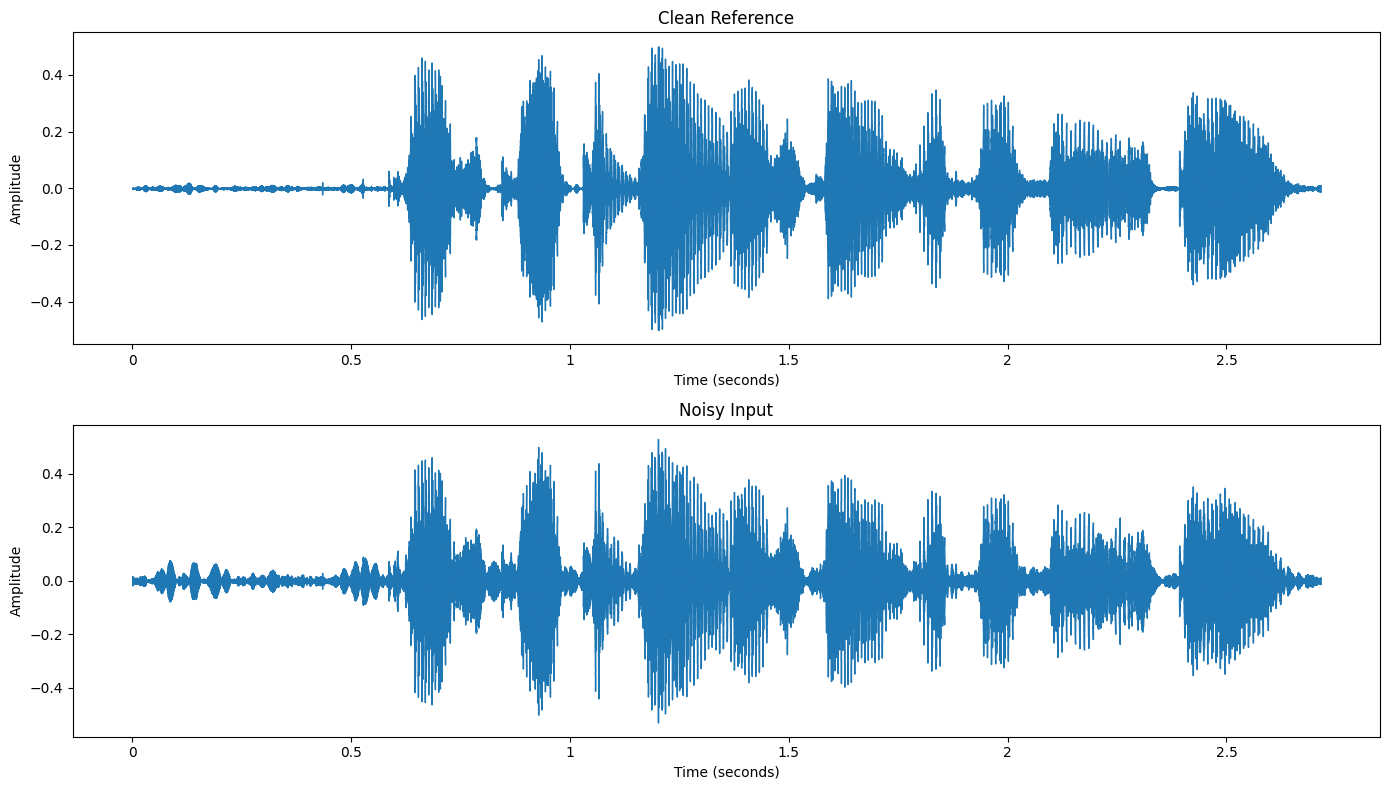

In [87]:
plt.figure(figsize=(14, 8))

plt.subplot(2, 1, 1)

librosa.display.waveshow(
    clean_audio_trim,
    sr=clean_fs
)

plt.title("Clean Reference")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.subplot(2, 1, 2)

librosa.display.waveshow(
    noisy_audio_trim,
    sr=noisy_fs
)

plt.title("Noisy Input")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()